In [17]:
import os
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from PIL import ImageOps
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [18]:
# Define model name
model_name = "resnet34"

# Create Individual Results directory structure
individual_results_dir = f"Individual Results/{model_name}"
train_dir = f"{individual_results_dir}/train"
test_dir = f"{individual_results_dir}/test"
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Dataset paths
YOLO_DATASET_PATH = r"CS2 Dataset/YOLO_COCO_sign_shape"
CLASSIFICATION_DATASET_PATH = f"{individual_results_dir}/YOLO_COCO_sign_shape_processed"

# Class names (from data.yaml)
CLASS_NAMES = ["Circular", "Damaged", "Octagonal", "Square", "Triangular"]
NUM_CLASSES = len(CLASS_NAMES)

# Training hyperparameters
BATCH_SIZE = 16
NUM_EPOCHS = 25
LEARNING_RATE = 0.0005
IMG_SIZE = 224  # ResNet input size
EARLY_STOP_PATIENCE = 5  # Stop if no improvement for 5 epochs

# Model save path
MODEL_SAVE_PATH = f"{train_dir}/best.pt"

In [19]:
def convert_yolo_to_classification(yolo_path, output_path, splits=['train', 'val', 'test']):
    """
    Convert YOLO detection dataset to classification dataset.
    Crops individual signs based on bounding boxes and organizes by class.
    
    Args:
        yolo_path: Path to YOLO dataset (contains images/ and labels/)
        output_path: Path to output classification dataset
        splits: List of dataset splits to process
    """
    print("Converting YOLO dataset to classification format...")
    
    for split in splits:
        images_dir = Path(yolo_path) / 'images' / split
        labels_dir = Path(yolo_path) / 'labels' / split
        
        if not images_dir.exists() or not labels_dir.exists():
            print(f"Warning: {split} split not found, skipping...")
            continue
        
        # Create output directories for each class
        for class_name in CLASS_NAMES:
            (Path(output_path) / split / class_name).mkdir(parents=True, exist_ok=True)
        
        # Process each image
        image_files = list(images_dir.glob('*.jpg')) + list(images_dir.glob('*.png'))
        
        sign_count = {class_name: 0 for class_name in CLASS_NAMES}
        
        for img_path in tqdm(image_files, desc=f"Processing {split}"):
            label_path = labels_dir / f"{img_path.stem}.txt"
            
            if not label_path.exists():
                continue
            
            # Read image and apply EXIF orientation
            try:
                img = Image.open(img_path)
                img = ImageOps.exif_transpose(img)  #Apply EXIF rotation
                img = img.convert('RGB')
                img_width, img_height = img.size
            except Exception as e:
                print(f"Error loading {img_path}: {e}")
                continue
            
            # Read YOLO labels
            with open(label_path, 'r') as f:
                lines = f.readlines()
            
            # Process each bounding box in the image
            for idx, line in enumerate(lines):
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                
                class_id = int(parts[0])
                center_x, center_y, width, height = map(float, parts[1:])
                
                # Convert YOLO format (normalized) to pixel coordinates
                x_center = center_x * img_width
                y_center = center_y * img_height
                box_width = width * img_width
                box_height = height * img_height
                
                # Add padding to avoid cutting off signs
                padding_factor = 0.05  # 5% padding
                box_width_padded = box_width * (1 + padding_factor)
                box_height_padded = box_height * (1 + padding_factor)
                
                # Calculate corner coordinates
                x1 = int(x_center - box_width_padded / 2)
                y1 = int(y_center - box_height_padded / 2)
                x2 = int(x_center + box_width_padded / 2)
                y2 = int(y_center + box_height_padded / 2)
                
                # Ensure coordinates are within image bounds
                x1 = max(0, x1)
                y1 = max(0, y1)
                x2 = min(img_width, x2)
                y2 = min(img_height, y2)
                
                
                # Crop the sign
                try:
                    cropped_sign = img.crop((x1, y1, x2, y2))
                    
                    # Save to appropriate class folder
                    class_name = CLASS_NAMES[class_id]
                    output_filename = f"{img_path.stem}_sign{idx}.jpg"
                    output_path_full = Path(output_path) / split / class_name / output_filename
                    cropped_sign.save(output_path_full)
                    
                    sign_count[class_name] += 1
                except Exception as e:
                    print(f"Error cropping sign from {img_path}: {e}")
        
        print(f"\n{split.upper()} split - Signs extracted:")
        for class_name, count in sign_count.items():
            print(f"  {class_name}: {count}")
        print()

# Run conversion
convert_yolo_to_classification(YOLO_DATASET_PATH, CLASSIFICATION_DATASET_PATH)

Converting YOLO dataset to classification format...


Processing train: 100%|██████████| 432/432 [00:39<00:00, 10.94it/s]



TRAIN split - Signs extracted:
  Circular: 291
  Damaged: 33
  Octagonal: 89
  Square: 70
  Triangular: 44



Processing val: 100%|██████████| 97/97 [00:08<00:00, 11.26it/s]



VAL split - Signs extracted:
  Circular: 67
  Damaged: 5
  Octagonal: 27
  Square: 9
  Triangular: 8



Processing test: 100%|██████████| 97/97 [00:08<00:00, 11.94it/s]


TEST split - Signs extracted:
  Circular: 62
  Damaged: 5
  Octagonal: 22
  Square: 19
  Triangular: 13



Dataset Statistics:
Split       test  train  val
Class                       
Circular      62    291   67
Damaged        5     33    5
Octagonal     22     89   27
Square        19     70    9
Triangular    13     44    8

Total samples: 764


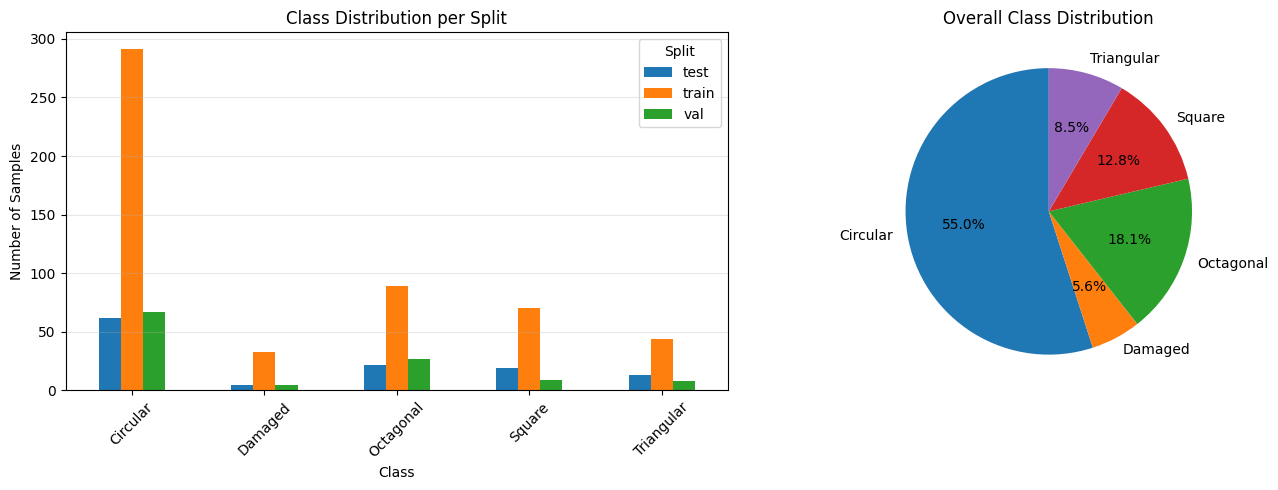

Saved dataset analysis to Individual Results/resnet34/train/dataset_analysis.png


In [20]:
def analyze_dataset(dataset_path, splits=['train', 'val', 'test']):
    # Analyze and visualize dataset distribution
    
    stats = []
    
    for split in splits:
        split_path = Path(dataset_path) / split
        if not split_path.exists():
            continue
        
        for class_name in CLASS_NAMES:
            class_path = split_path / class_name
            if class_path.exists():
                count = len(list(class_path.glob('*.jpg')))
                stats.append({
                    'Split': split,
                    'Class': class_name,
                    'Count': count
                })
    
    df = pd.DataFrame(stats)
    
    # Display statistics
    print("Dataset Statistics:")
    pivot_table = df.pivot(index='Class', columns='Split', values='Count').fillna(0).astype(int)
    print(pivot_table)
    print()
    print(f"Total samples: {df['Count'].sum()}")
    
    # Visualize distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot per split
    df_pivot = df.pivot(index='Class', columns='Split', values='Count')
    df_pivot.plot(kind='bar', ax=axes[0], rot=45)
    axes[0].set_title('Class Distribution per Split')
    axes[0].set_ylabel('Number of Samples')
    axes[0].legend(title='Split')
    axes[0].grid(axis='y', alpha=0.3)
    
    # Pie chart for total distribution
    class_totals = df.groupby('Class')['Count'].sum()
    axes[1].pie(class_totals, labels=class_totals.index, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Overall Class Distribution')
    
    plt.tight_layout()
    plt.savefig(f"{train_dir}/dataset_analysis.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved dataset analysis to {train_dir}/dataset_analysis.png")
    
    return df

# Analyze the dataset
dataset_stats = analyze_dataset(CLASSIFICATION_DATASET_PATH)

In [21]:
class SignShapeDataset(Dataset):
    # Custom Dataset for Sign Shape Classification
    
    def __init__(self, root_dir, split='train', transform=None):
        """
        Args:
            root_dir: Root directory of classification dataset
            split: 'train', 'val', or 'test'
            transform: Optional transform to be applied on images
        """
        self.root_dir = Path(root_dir) / split
        self.transform = transform
        self.classes = CLASS_NAMES
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        
        # Load all image paths and labels
        self.samples = []
        for class_name in self.classes:
            class_dir = self.root_dir / class_name
            if not class_dir.exists():
                continue
            
            for img_path in class_dir.glob('*.jpg'):
                self.samples.append((str(img_path), self.class_to_idx[class_name]))
        
        print(f"{split.upper()} dataset: {len(self.samples)} samples")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        
        # Load image
        image = Image.open(img_path).convert('RGB')
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [22]:
# Define data transforms
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])  # ImageNet normalization
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = SignShapeDataset(CLASSIFICATION_DATASET_PATH, split='train', transform=train_transform)
val_dataset = SignShapeDataset(CLASSIFICATION_DATASET_PATH, split='val', transform=val_test_transform)
test_dataset = SignShapeDataset(CLASSIFICATION_DATASET_PATH, split='test', transform=val_test_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"\nDataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

TRAIN dataset: 527 samples
VAL dataset: 116 samples
TEST dataset: 121 samples

DataLoaders created:
  Train batches: 33
  Val batches: 8
  Test batches: 8


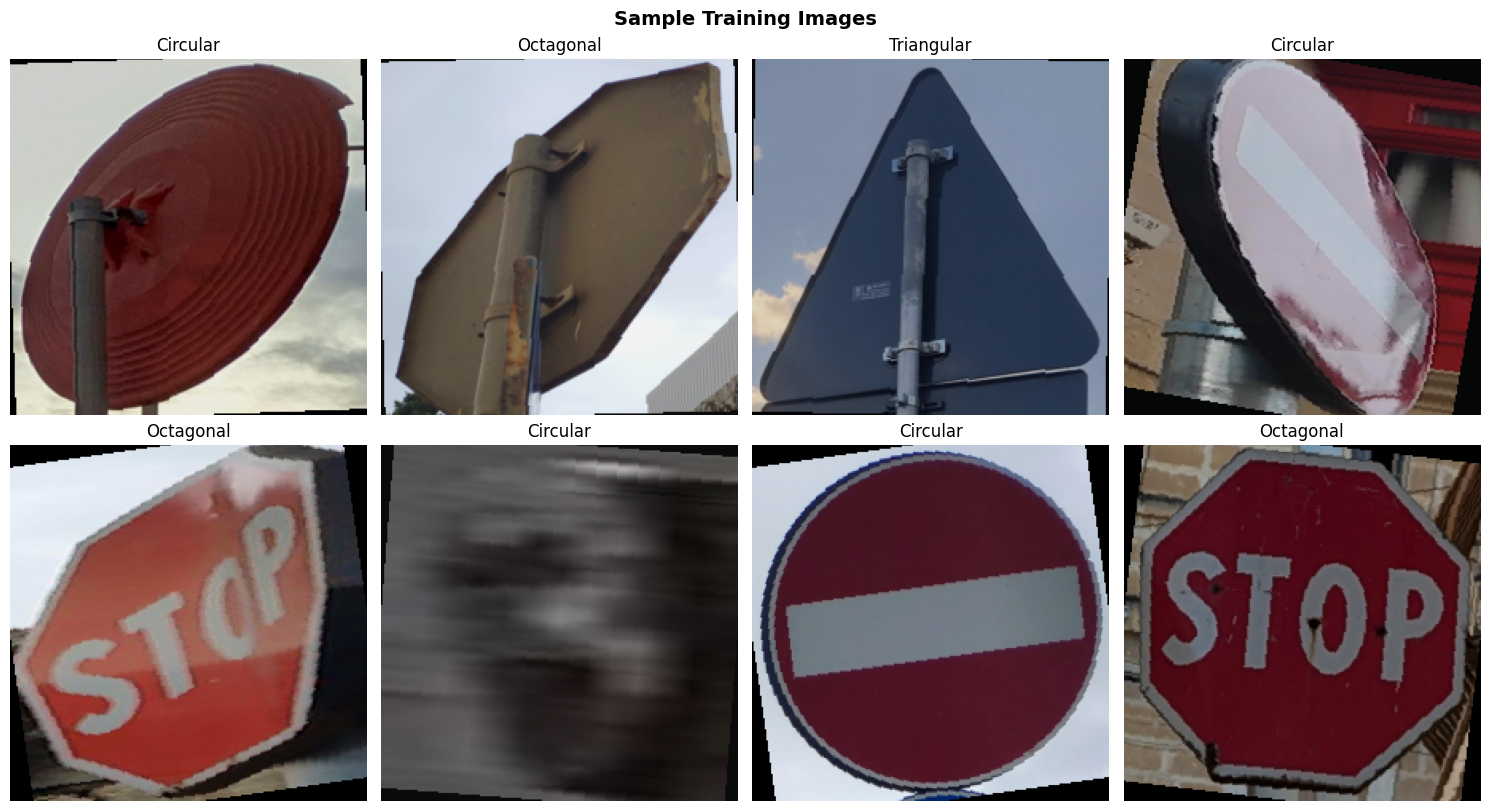

Saved sample images to Individual Results/resnet34/train/sample_images.png


In [23]:
def imshow(img, title=None):
    # Display image tensor
    # Denormalize
    img = img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# Get a batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Plot sample images
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
axes = axes.ravel()

for idx in range(min(8, len(images))):
    ax = axes[idx]
    plt.sca(ax)
    imshow(images[idx], title=CLASS_NAMES[labels[idx]])

plt.tight_layout()
plt.suptitle('Sample Training Images', y=1.02, fontsize=14, fontweight='bold')
plt.show()
plt.savefig(f"{train_dir}/sample_images.png", dpi=300, bbox_inches='tight')
plt.close()
print(f"Saved sample images to {train_dir}/sample_images.png")

In [24]:
# Load pretrained ResNet-34
model = models.resnet34(pretrained=True)

# Modify the final fully connected layer for our number of classes
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, NUM_CLASSES)

# Move model to device
model = model.to(device)

# Calculate class weights for handling imbalance
def calculate_class_weights(dataset_path, splits=['train']):
    # Calculate inverse frequency weights for each class
    class_counts = {class_name: 0 for class_name in CLASS_NAMES}
    
    for split in splits:
        split_path = Path(dataset_path) / split
        for class_name in CLASS_NAMES:
            class_path = split_path / class_name
            if class_path.exists():
                class_counts[class_name] = len(list(class_path.glob('*.jpg')))
    
    total = sum(class_counts.values())
    weights = [total / (len(CLASS_NAMES) * class_counts[cls]) for cls in CLASS_NAMES]
    
    print("\nClass Distribution & Weights:")
    for cls, count in class_counts.items():
        weight = weights[CLASS_NAMES.index(cls)]
        print(f"  {cls:12} | Count: {count:4} | Weight: {weight:.4f}")
    
    return torch.FloatTensor(weights)

# Get class weights
class_weights = calculate_class_weights(CLASSIFICATION_DATASET_PATH).to(device)

# Weighted loss function
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer and scheduler
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

print("\nModel Architecture:")
print(f"  Base: ResNet-34 (pretrained on ImageNet)")
print(f"  Input: {IMG_SIZE}x{IMG_SIZE}x3")
print(f"  Output: {NUM_CLASSES} classes")
print(f"  Loss: CrossEntropyLoss with class weights")
print(f"  Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

c:\Users\matth\Desktop\Computer Vision 2\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\matth\Desktop\Computer Vision 2\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Class Distribution & Weights:
  Circular     | Count:  291 | Weight: 0.3622
  Damaged      | Count:   33 | Weight: 3.1939
  Octagonal    | Count:   89 | Weight: 1.1843
  Square       | Count:   70 | Weight: 1.5057
  Triangular   | Count:   44 | Weight: 2.3955

Model Architecture:
  Base: ResNet-34 (pretrained on ImageNet)
  Input: 224x224x3
  Output: 5 classes
  Loss: CrossEntropyLoss with class weights
  Total parameters: 21,287,237
  Trainable parameters: 21,287,237


In [25]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    # Train for one epoch
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    progress_bar = tqdm(dataloader, desc="Training")
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        progress_bar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100 * correct / total:.2f}%'
        })
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

def validate(model, dataloader, criterion, device):
    # Validate the model
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
best_epoch = 0
patience_counter = 0

print(f"Starting training for up to {NUM_EPOCHS} epochs...")
print(f"Early stopping patience: {EARLY_STOP_PATIENCE} epochs")

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}:")
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print epoch results
    print(f"Results:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc*100:.2f}%")
    
    # Check for improvement
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'train_loss': train_loss,
        }, MODEL_SAVE_PATH)
        print(f"  New best model saved! (Val Acc: {val_acc*100:.2f}%)")
    else:
        patience_counter += 1
        print(f"  No improvement for {patience_counter} epoch(s)")
        
        # Early stopping check
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping triggered! No improvement for {EARLY_STOP_PATIENCE} epochs.")
            print(f"Best model from epoch {best_epoch+1} with Val Acc: {best_val_acc*100:.2f}%")
            break

print(f"\nTraining completed!")
print(f"Best epoch: {best_epoch+1}")
print(f"Best validation accuracy: {best_val_acc*100:.2f}%")
print(f"Total epochs trained: {len(history['train_loss'])}")

# Save training history to CSV
history_df = pd.DataFrame(history)
history_df.insert(0, 'epoch', range(1, len(history_df) + 1))
history_df.to_csv(f"{train_dir}/training_history.csv", index=False)
print(f"Saved training history to {train_dir}/training_history.csv")

Starting training for up to 25 epochs...
Early stopping patience: 5 epochs

Epoch 1/25:


Validation: 100%|██████████| 8/8 [00:01<00:00,  5.30it/s]


Results:
  Train Loss: 1.1717 | Train Acc: 55.98%
  Val Loss:   1.6418 | Val Acc:   50.86%
  New best model saved! (Val Acc: 50.86%)

Epoch 2/25:


Validation: 100%|██████████| 8/8 [00:00<00:00, 14.40it/s]


Results:
  Train Loss: 1.1000 | Train Acc: 55.22%
  Val Loss:   0.8803 | Val Acc:   65.52%
  New best model saved! (Val Acc: 65.52%)

Epoch 3/25:


...

Results:
  Train Loss: 0.4449 | Train Acc: 84.82%
  Val Loss:   0.6126 | Val Acc:   81.90%
  No improvement for 3 epoch(s)

Epoch 11/25:


Validation: 100%|██████████| 8/8 [00:00<00:00, 12.69it/s]


Results:
  Train Loss: 0.2729 | Train Acc: 88.05%
  Val Loss:   1.5514 | Val Acc:   68.10%
  No improvement for 4 epoch(s)

Epoch 12/25:


Validation: 100%|██████████| 8/8 [00:00<00:00, 12.11it/s]

Results:
  Train Loss: 0.4483 | Train Acc: 84.06%
  Val Loss:   0.7019 | Val Acc:   74.14%
  No improvement for 5 epoch(s)

Early stopping triggered! No improvement for 5 epochs.
Best model from epoch 7 with Val Acc: 84.48%

Training completed!
Best epoch: 7
Best validation accuracy: 84.48%
Total epochs trained: 12
Saved training history to Individual Results/resnet34/train/training_history.csv


In [26]:
# Plot training history with best model marker
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Use actual number of epochs trained (not NUM_EPOCHS)
actual_epochs = len(history['train_loss'])
epochs_range = range(1, actual_epochs + 1)

# Find best epoch
best_epoch_idx = history['val_acc'].index(max(history['val_acc']))
best_epoch_num = best_epoch_idx + 1

# Plot loss
ax1.plot(epochs_range, history['train_loss'], label='Train Loss', marker='o')
ax1.plot(epochs_range, history['val_loss'], label='Val Loss', marker='s')
ax1.axvline(x=best_epoch_num, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Best Model (Epoch {best_epoch_num})')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(epochs_range, [acc*100 for acc in history['train_acc']], label='Train Acc', marker='o')
ax2.plot(epochs_range, [acc*100 for acc in history['val_acc']], label='Val Acc', marker='s')
ax2.axvline(x=best_epoch_num, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label=f'Best Model (Epoch {best_epoch_num})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{train_dir}/training_curves.png", dpi=300, bbox_inches='tight')
plt.close()
print(f"Saved training curves to {train_dir}/training_curves.png")

print(f"\nTraining Summary:")
print(f"  Total epochs trained: {actual_epochs}")
print(f"  Best model saved at: Epoch {best_epoch_num}")
print(f"  Best validation accuracy: {max(history['val_acc'])*100:.2f}%")
print(f"  Final train accuracy: {history['train_acc'][-1]*100:.2f}%")
print(f"  Final val accuracy: {history['val_acc'][-1]*100:.2f}%")
print(f"  Early stopping triggered: {'Yes' if actual_epochs < NUM_EPOCHS else 'No'}")

Saved training curves to Individual Results/resnet34/train/training_curves.png

Training Summary:
  Total epochs trained: 12
  Best model saved at: Epoch 7
  Best validation accuracy: 84.48%
  Final train accuracy: 84.06%
  Final val accuracy: 74.14%
  Early stopping triggered: Yes


In [27]:
# Load best model
checkpoint = torch.load(MODEL_SAVE_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"  Val Accuracy: {checkpoint['val_acc']*100:.2f}%")

# Evaluate on test set
def evaluate_model(model, dataloader, device):
    # Evaluate model and return predictions
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Testing"):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Get predictions
true_labels, predictions, probabilities = evaluate_model(model, test_loader, device)

# Calculate accuracy
test_accuracy = accuracy_score(true_labels, predictions)
print(f"Test Set Accuracy: {test_accuracy*100:.2f}%")

Loaded best model from epoch 7
  Val Accuracy: 84.48%


Testing: 100%|██████████| 8/8 [00:01<00:00,  4.69it/s]

Test Set Accuracy: 84.30%


In [ ]:
# Generate classification report
report = classification_report(true_labels, predictions, 
                               target_names=CLASS_NAMES, 
                               digits=4)
print("\nClassification Report:")
print(report)

# Create DataFrame for better visualization
report_dict = classification_report(true_labels, predictions, 
                                    target_names=CLASS_NAMES, 
                                    output_dict=True)
df_report = pd.DataFrame(report_dict).transpose()
print("\nPer-Class Metrics:")
print(df_report.round(4))

# Save classification report to CSV
df_report.to_csv(f"{test_dir}/classification_report.csv")
print(f"Saved classification report to {test_dir}/classification_report.csv")


Classification Report:
              precision    recall  f1-score   support

    Circular     0.8788    0.9355    0.9062        62
     Damaged     0.1250    0.2000    0.1538         5
   Octagonal     0.9333    0.6364    0.7568        22
      Square     0.9000    0.9474    0.9231        19
  Triangular     0.9167    0.8462    0.8800        13

    accuracy                         0.8430       121
   macro avg     0.7508    0.7131    0.7240       121
weighted avg     0.8650    0.8430    0.8478       121


Per-Class Metrics:
              precision  recall  f1-score  support
Circular         0.8788  0.9355    0.9062   62.000
Damaged          0.1250  0.2000    0.1538    5.000
Octagonal        0.9333  0.6364    0.7568   22.000
Square           0.9000  0.9474    0.9231   19.000
Triangular       0.9167  0.8462    0.8800   13.000
accuracy         0.8430  0.8430    0.8430    0.843
macro avg        0.7508  0.7131    0.7240  121.000
weighted avg     0.8650  0.8430    0.8478  121.000
Saved cl

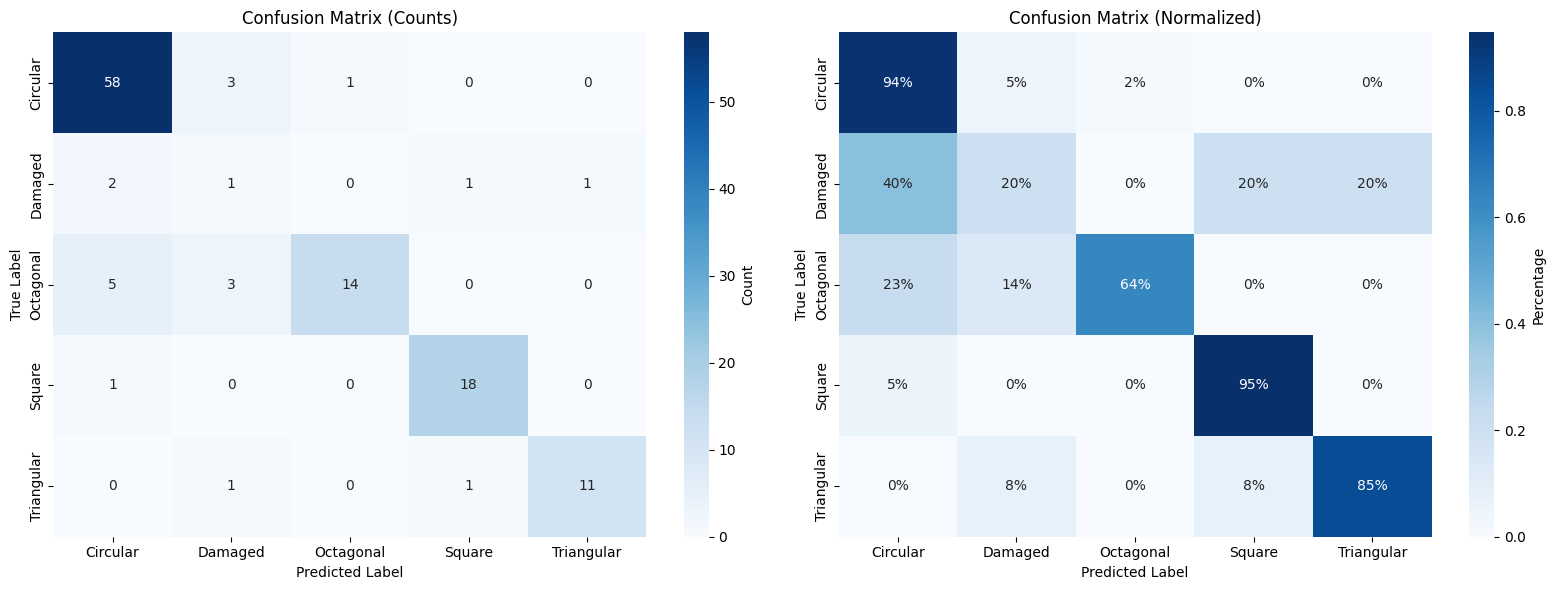

Saved confusion matrix to Individual Results/resnet34/test/confusion_matrix.png


In [29]:
# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Plot confusion matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, 
            ax=ax1, cbar_kws={'label': 'Count'})
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')
ax1.set_title('Confusion Matrix (Counts)')

# Normalized (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.0%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax2, cbar_kws={'label': 'Percentage'})
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')
ax2.set_title('Confusion Matrix (Normalized)')

plt.tight_layout()
plt.savefig(f"{test_dir}/confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved confusion matrix to {test_dir}/confusion_matrix.png")

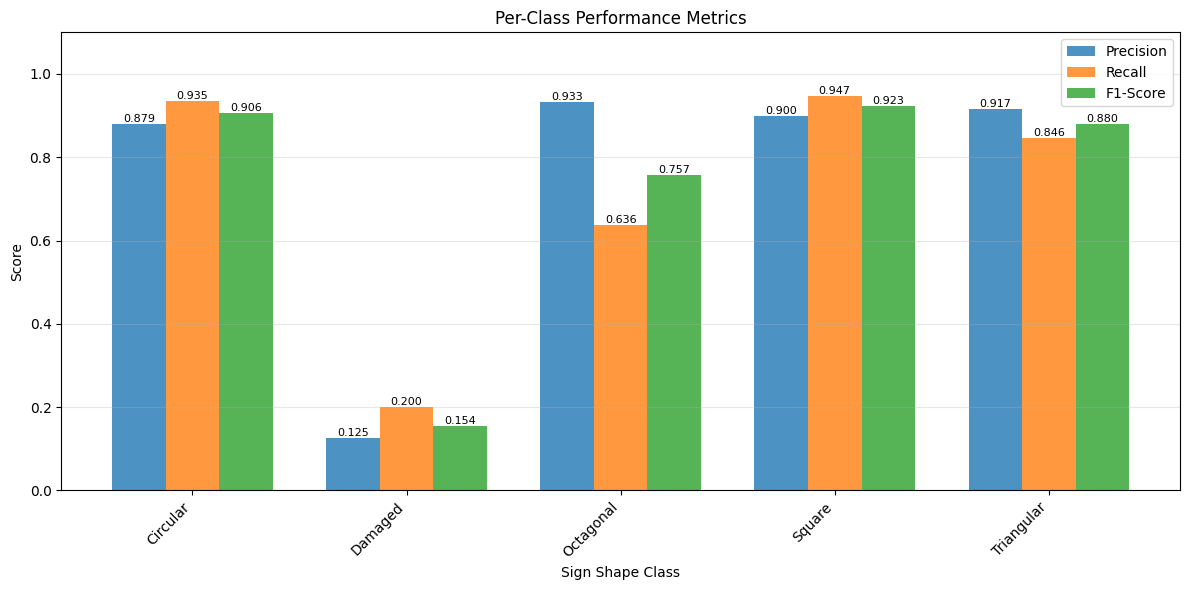

Saved per-class metrics to Individual Results/resnet34/test/per_class_metrics.png


In [30]:
# Extract per-class metrics
precision = [report_dict[cls]['precision'] for cls in CLASS_NAMES]
recall = [report_dict[cls]['recall'] for cls in CLASS_NAMES]
f1_score = [report_dict[cls]['f1-score'] for cls in CLASS_NAMES]

# Create bar plot
x = np.arange(len(CLASS_NAMES))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width, precision, width, label='Precision', alpha=0.8)
bars2 = ax.bar(x, recall, width, label='Recall', alpha=0.8)
bars3 = ax.bar(x + width, f1_score, width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Sign Shape Class')
ax.set_ylabel('Score')
ax.set_title('Per-Class Performance Metrics')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f"{test_dir}/per_class_metrics.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"Saved per-class metrics to {test_dir}/per_class_metrics.png")

In [31]:
# Create Group Results directory and save metrics CSV
group_results_dir = "Group Results"
os.makedirs(group_results_dir, exist_ok=True)

# Calculate overall metrics from classification report
overall_precision = report_dict['weighted avg']['precision']
overall_recall = report_dict['weighted avg']['recall']
overall_f1 = report_dict['weighted avg']['f1-score']

# Create metrics dataframe
metrics_df = pd.DataFrame({
    'Model Name': ['ResNet34'],
    'Test Accuracy': [test_accuracy],
    'Precision': [overall_precision],
    'Recall': [overall_recall],
    'F1-Score': [overall_f1],
    'Best Val Accuracy': [best_val_acc],
    'Epochs Trained': [len(history['train_loss'])],
    'Best Epoch': [best_epoch_num]
})

# Save to CSV
csv_path = os.path.join(group_results_dir, f"{model_name}.csv")
metrics_df.to_csv(csv_path, index=False)
print(f"\nSaved metrics to {csv_path}")

# Print comparison metrics
print(f"\nModel: ResNet34")
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Precision: {overall_precision:.4f}")
print(f"Recall: {overall_recall:.4f}")
print(f"F1-Score: {overall_f1:.4f}")
print(f"Best Val Accuracy: {best_val_acc:.4f}")


Saved metrics to Group Results\resnet34.csv

Model: ResNet34
Test Accuracy: 0.8430
Precision: 0.8650
Recall: 0.8430
F1-Score: 0.8478
Best Val Accuracy: 0.8448


In [32]:
# Copy best model to Models directory
models_dir = "Models"
os.makedirs(models_dir, exist_ok=True)
shutil.copy(MODEL_SAVE_PATH, os.path.join(models_dir, f'{model_name}.pt'))
print(f"Copied best model to Models/{model_name}.pt")

Copied best model to Models/resnet34.pt


Loading model from Models/resnet34.pt...
Model loaded successfully!
TEST dataset: 121 samples
Generating predictions on test set...


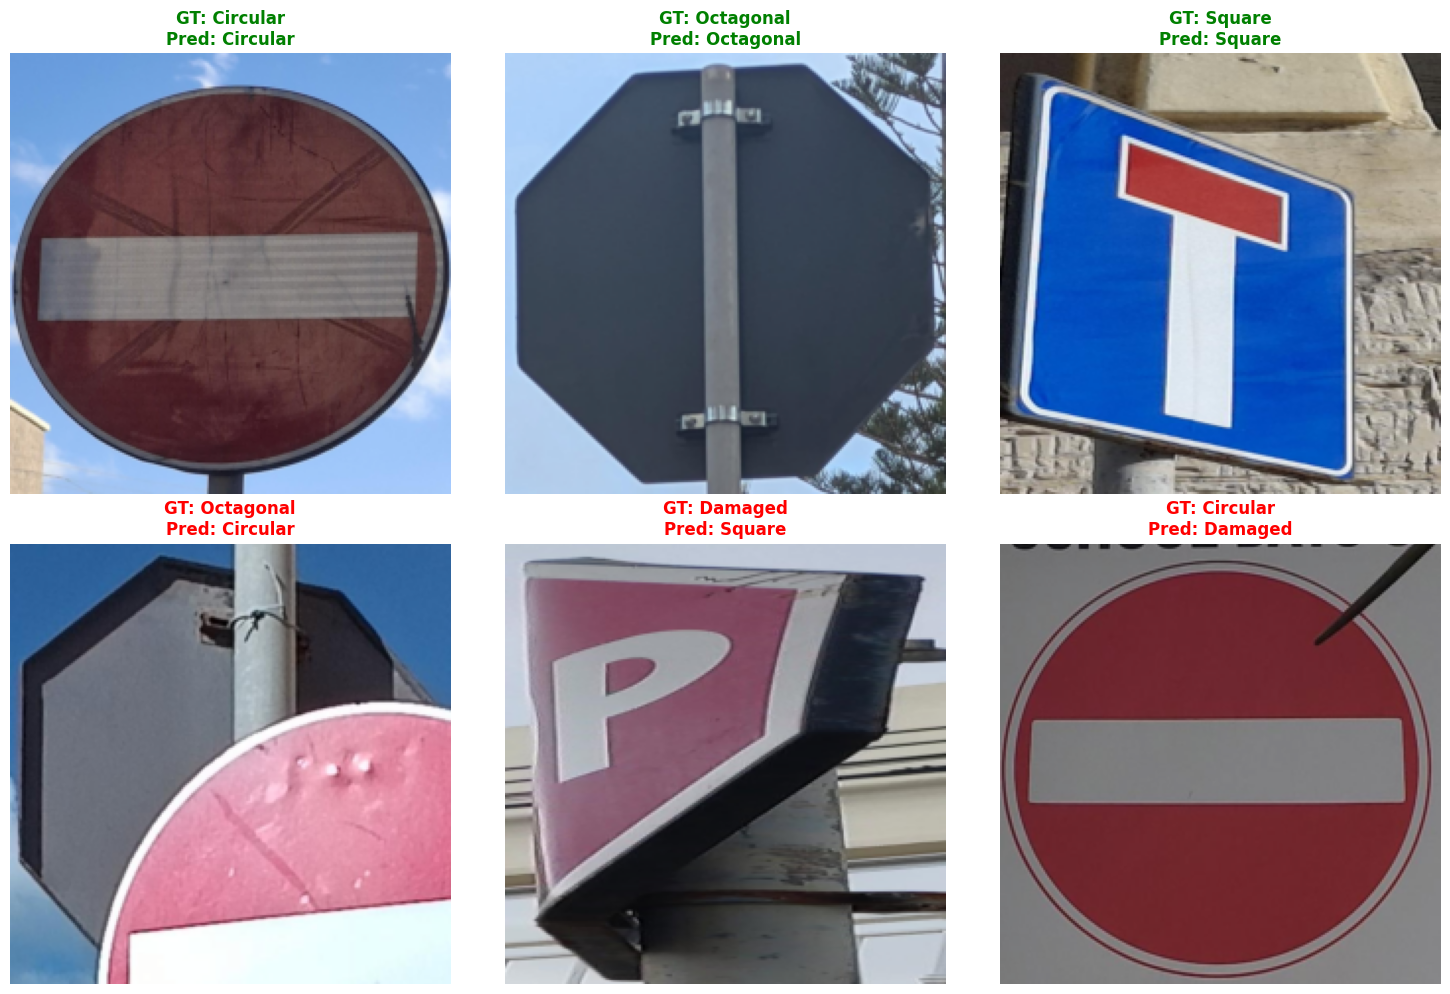


Saved qualitative examples to Individual Results/resnet34/test/qualitative_examples.png
Generated 6 example(s)

Examples shown:
  1. GT: Circular     | Pred: Circular     | ✓ Correct
  2. GT: Octagonal    | Pred: Octagonal    | ✓ Correct
  3. GT: Square       | Pred: Square       | ✓ Correct
  4. GT: Octagonal    | Pred: Circular     | ✗ Misclassified
  5. GT: Damaged      | Pred: Square       | ✗ Misclassified
  6. GT: Circular     | Pred: Damaged      | ✗ Misclassified


In [ ]:
# Can be run independently after training

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn

# Configuration (matches your existing setup)
model_name = "resnet34"
individual_results_dir = f"Individual Results/{model_name}"
test_dir = f"{individual_results_dir}/test"
MODEL_PATH = f"Models/{model_name}.pt"  # Or use f"{individual_results_dir}/train/best.pt"
CLASSIFICATION_DATASET_PATH = f"{individual_results_dir}/YOLO_COCO_sign_shape_processed"

CLASS_NAMES = ["Circular", "Damaged", "Octagonal", "Square", "Triangular"]
IMG_SIZE = 224
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Define SignShapeDataset class (copied from your training script)
class SignShapeDataset(Dataset):
    """Custom Dataset for Sign Shape Classification"""
    
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = Path(root_dir) / split
        self.transform = transform
        self.classes = CLASS_NAMES
        self.class_to_idx = {cls_name: idx for idx, cls_name in enumerate(self.classes)}
        
        # Load all image paths and labels
        self.samples = []
        for class_name in self.classes:
            class_dir = self.root_dir / class_name
            if not class_dir.exists():
                continue
            
            for img_path in class_dir.glob('*.jpg'):
                self.samples.append((str(img_path), self.class_to_idx[class_name]))
        
        print(f"{split.upper()} dataset: {len(self.samples)} samples")
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label

# Check if model exists
if not Path(MODEL_PATH).exists():
    print(f"Error: Model not found at {MODEL_PATH}")
    print("Please train the model first or check the path.")
else:
    print(f"Loading model from {MODEL_PATH}...")
    
    # Recreate model architecture
    model = models.resnet34(pretrained=False)
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, len(CLASS_NAMES))
    
    # Load weights
    checkpoint = torch.load(MODEL_PATH, map_location=device)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    model = model.to(device)
    model.eval()
    print("Model loaded successfully!")
    
    # Recreate test dataset and loader
    val_test_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                            std=[0.229, 0.224, 0.225])
    ])
    
    test_dataset = SignShapeDataset(CLASSIFICATION_DATASET_PATH, split='test', transform=val_test_transform)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=0)
    
    # Get all predictions
    print("Generating predictions on test set...")
    all_images = []
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images_device = images.to(device)
            outputs = model(images_device)
            _, predicted = torch.max(outputs, 1)
            
            all_images.extend(images.cpu())
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
    
    all_images = torch.stack(all_images)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    
    # Function to denormalize images
    def denormalize(img_tensor):
        img = img_tensor.numpy().transpose((1, 2, 0))
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        img = std * img + mean
        img = np.clip(img, 0, 1)
        return img
    
    # Select interesting examples
    examples = []
    
    # Strategy: Get 2-3 correct predictions from major classes + 2-3 interesting misclassifications
    
    # 1. Correct predictions - one from each major class
    for class_idx in [0, 2, 3]:  # Circular, Octagonal, Square
        correct_mask = (all_labels == class_idx) & (all_preds == class_idx)
        correct_indices = np.where(correct_mask)[0]
        if len(correct_indices) > 0:
            idx = correct_indices[0]
            examples.append((idx, all_labels[idx], all_preds[idx], True))
    
    # 2. Interesting misclassifications
    # Octagonal → Circular (geometric confusion)
    oct_to_circ = np.where((all_labels == 2) & (all_preds == 0))[0]
    if len(oct_to_circ) > 0:
        examples.append((oct_to_circ[0], all_labels[oct_to_circ[0]], all_preds[oct_to_circ[0]], False))
    
    # Damaged → anything (labeling ambiguity)
    damaged_wrong = np.where((all_labels == 1) & (all_preds != 1))[0]
    if len(damaged_wrong) > 0:
        examples.append((damaged_wrong[0], all_labels[damaged_wrong[0]], all_preds[damaged_wrong[0]], False))
    
    # Any other misclassification to fill to 6 examples
    all_wrong = np.where(all_labels != all_preds)[0]
    for idx in all_wrong:
        if len(examples) >= 6:
            break
        # Avoid duplicates
        if not any(ex[0] == idx for ex in examples):
            examples.append((idx, all_labels[idx], all_preds[idx], False))
    
    # If we don't have 6 yet, pad with more correct examples
    all_correct = np.where(all_labels == all_preds)[0]
    for idx in all_correct:
        if len(examples) >= 6:
            break
        if not any(ex[0] == idx for ex in examples):
            examples.append((idx, all_labels[idx], all_preds[idx], True))
    
    # Limit to 6 examples (3x2 grid)
    examples = examples[:6]
    
    # Plot qualitative examples
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for i, (idx, true_label, pred_label, is_correct) in enumerate(examples):
        ax = axes[i]
        
        # Denormalize and display image
        img = denormalize(all_images[idx])
        ax.imshow(img)
        
        # Create title with GT and Pred
        gt_text = f"GT: {CLASS_NAMES[true_label]}"
        pred_text = f"Pred: {CLASS_NAMES[pred_label]}"
        title_text = f"{gt_text}\n{pred_text}"
        
        # Color: green if correct, red if wrong
        color = 'green' if is_correct else 'red'
        ax.set_title(title_text, fontsize=12, fontweight='bold', color=color)
        ax.axis('off')
    
    # Hide any unused subplots
    for i in range(len(examples), 6):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig(f"{test_dir}/qualitative_examples.png", dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print(f"\nSaved qualitative examples to {test_dir}/qualitative_examples.png")
    print(f"Generated {len(examples)} example(s)")
    print("\nExamples shown:")
    for i, (idx, true_label, pred_label, is_correct) in enumerate(examples):
        status = "✓ Correct" if is_correct else "✗ Misclassified"
        print(f"  {i+1}. GT: {CLASS_NAMES[true_label]:12} | Pred: {CLASS_NAMES[pred_label]:12} | {status}")